# Cloud-Native Data Pipeline: Remote Access, Subset & Analyze

This notebook demonstrates a cloud-native workflow for working with MPAS model output:

1. **Remote Access** — Connect to MPAS data hosted on THREDDS OPeNDAP servers (lazy, on-demand access — no full download required)
2. **Spatial Subsetting** — Crop the domain to a region of interest using `get_subset()`
3. **Derived Variables** — Compute new fields efficiently on the smaller subset
4. **Visualization** — Build multi-panel dashboards and extract point time series

The key idea: access only what you need, compute only where you need it, and visualize the results — all without downloading the full dataset to disk.

In [1]:
from mpasviewer import scvtmesh
import cartopy.crs as ccrs
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from earthcmap import escmap

## Step 1: Access Remote Data via THREDDS

THREDDS OPeNDAP allows us to access NetCDF data over HTTP without downloading the entire file. The `scvtmesh` class handles this transparently — you simply pass URLs instead of local paths.

We will load NYC-area MPAS output hosted on HydroShare THREDDS, spanning a 24-hour period.

In [2]:
url_thredds = "https://thredds.hydroshare.org/thredds/catalog/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_out/catalog.html"
inidt = datetime(2021, 9, 1, 13)
enddt = datetime(2021, 9, 2, 12)

list_files = scvtmesh.get_thredds_list(url_thredds, date_start=inidt, date_end=enddt)
print(f"Found {len(list_files)} remote files")
print(f"First: {list_files[0]}")
print(f"Last:  {list_files[-1]}")

Found 24 remote files
First: https://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_out/diag.2021-09-01_17.00.00.nc
Last:  https://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_out/diag.2021-09-01_15.00.00.nc


In [3]:
grid_url = 'http://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_static/nyc.static.nc'
mpasd = scvtmesh(grid_file=grid_url, diag_list=list_files)
mpasd.dataset(load_variables=['t2m', 'rainnc', 'rainc', 'u10', 'v10', 'refl10cm_max', 'cape', 'mslp'])
mpasd.rain_rate()
dta = mpasd.load()
print(f"Full domain: {len(dta['face_x'])} cells")

/Users/ss4338/mpasviewer/src/mpasviewer/main.py:101: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  outgrid = xr.open_mfdataset(allfls, combine='nested', concat_dim='Time', decode_cf=True, mask_and_scale=False)


Loaded grid_file dataset: http://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_static/nyc.static.nc
Full domain: 27862 cells


## Step 2: Spatial Subsetting

Once data is loaded, we can crop it to any rectangular region using `get_subset()`. This operates on the already-loaded data — no re-downloading needed. The subset retains the full unstructured mesh topology within the bounding box, so all visualization and analysis methods continue to work.

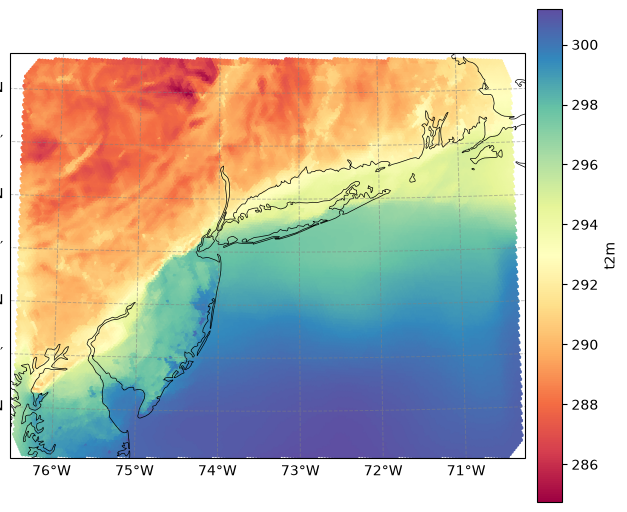

In [4]:
# Full domain view
mpasd.show(dta, var_name='t2m', time_index=12, figsize=(8, 8))

NYC subset: 843 cells (from 27862)


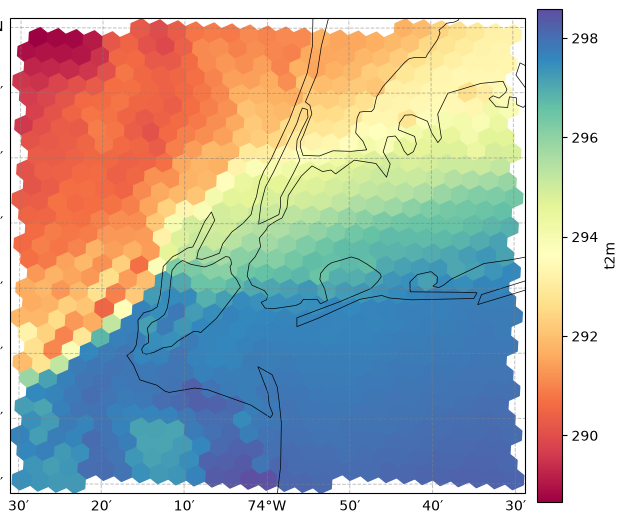

In [5]:
# NYC metro area subset
nyc_sub = mpasd.get_subset(dta, lon=(-74.5, -73.5), lat=(40.3, 41.0))
print(f"NYC subset: {len(nyc_sub['face_x'])} cells (from {len(dta['face_x'])})")

mpasd.show(nyc_sub, var_name='t2m', time_index=12, figsize=(8, 8))

NJ/NY subset: 6038 cells


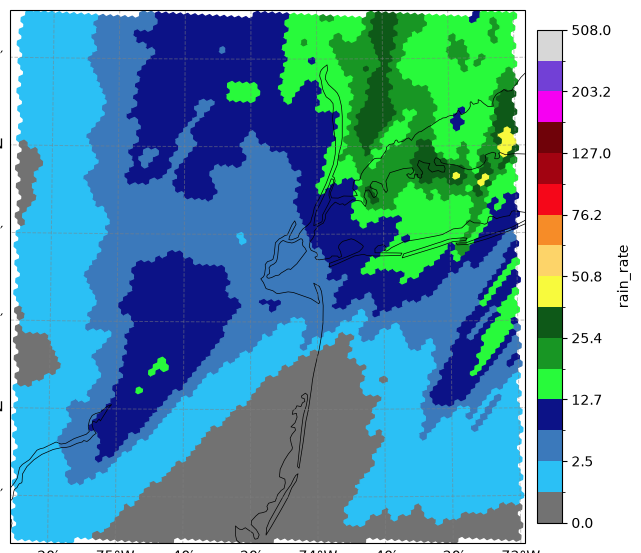

In [6]:
# Broader NJ/NY region
nj_sub = mpasd.get_subset(dta, lon=(-75.5, -73.0), lat=(39.5, 41.5))
print(f"NJ/NY subset: {len(nj_sub['face_x'])} cells")

cmap_r, norm_r = escmap("nwps_qpe", units="mm")
mpasd.show(nj_sub, var_name='rain_rate', time_index=15, figsize=(8, 8), cmap=cmap_r, norm=norm_r)

## Step 3: Compute Derived Variables on Subset

A major advantage of subsetting first: derived variable computations run on fewer cells, making them faster and more memory-efficient. Here we compute 10m wind speed from the U and V components on the NJ/NY subset.

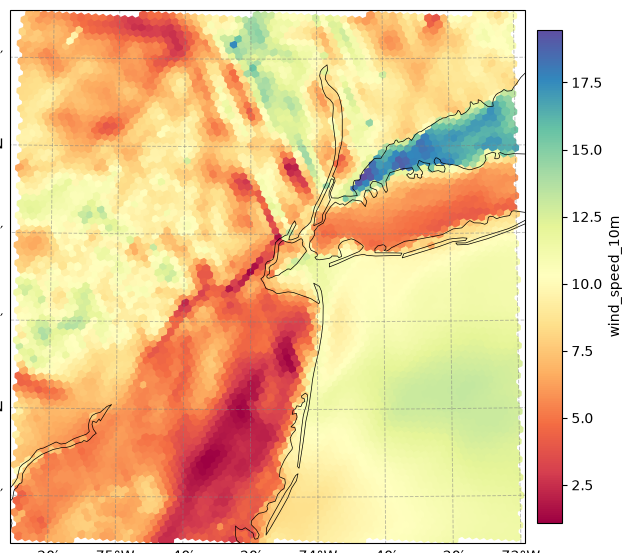

In [7]:
# Compute wind speed on the subset (efficient: fewer cells)
wind_speed = np.sqrt(nj_sub['u10']**2 + nj_sub['v10']**2)
wind_speed.attrs = {'long_name': 'Wind Speed 10m', 'units': 'm/s', 'var_name': 'wind_speed_10m'}
nj_sub['wind_speed_10m'] = wind_speed

mpasd.show(nj_sub, var_name='wind_speed_10m', time_index=12, figsize=(8, 8))

## Step 4: Multi-Variable Dashboard

With the subset and derived variables ready, we can build a four-panel dashboard showing multiple fields simultaneously. This gives a comprehensive view of weather conditions across the region at a single time step.

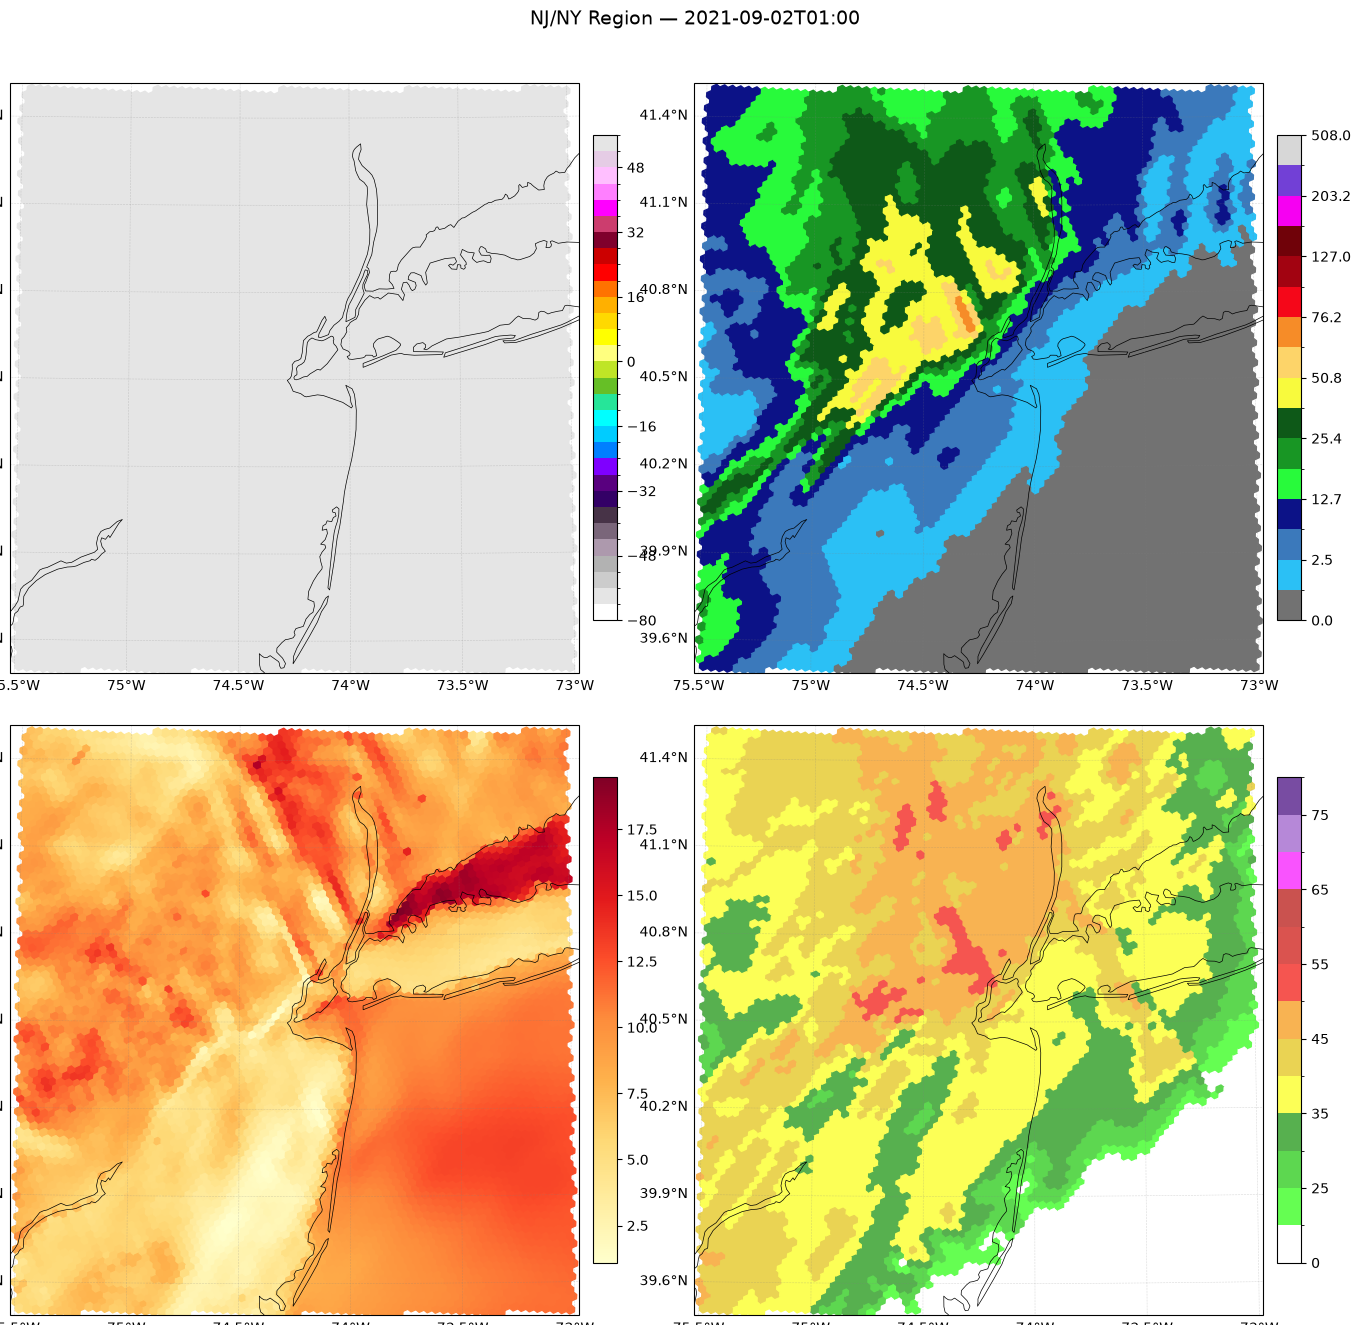

In [8]:
time_idx = 12
variables = ['t2m', 'rain_rate', 'wind_speed_10m', 'refl10cm_max']
cmaps = [
    escmap("temp_ecmwf"),
    escmap("nwps_qpe", units="mm"),
    (plt.cm.YlOrRd, None),  # wind speed: auto-range
    escmap("wofs_radar"),
]
titles = ['2m Temperature', 'Rain Rate', '10m Wind Speed', 'Max Reflectivity']

crs_proj = ccrs.Orthographic(
    central_longitude=float(nj_sub['face_x'].mean()),
    central_latitude=float(nj_sub['face_y'].mean())
)

fig, axes = plt.subplots(2, 2, figsize=(14, 14), subplot_kw={'projection': crs_proj})

for ax, var, (cmap, norm), title in zip(axes.flat, variables, cmaps, titles):
    if norm is not None:
        coll = mpasd.collection(nj_sub, var_name=var, time_index=time_idx,
                                figsize=(7,7), cmap=cmap, norm=norm)
    else:
        coll = mpasd.collection(nj_sub, var_name=var, time_index=time_idx,
                                figsize=(7,7), cmap=cmap)
    ax.add_collection(coll)
    ax.autoscale_view()
    ax.coastlines(linewidth=0.5)
    ax.set_extent(coll.limits, crs=ccrs.PlateCarree())
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.4, color='gray', alpha=0.3, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(title)
    fig.colorbar(coll, ax=ax, shrink=0.7, pad=0.02)

    # Patch GeoAxes tightbbox for Jupyter
    _orig = ax.get_tightbbox
    def _patch(renderer=None, _orig=_orig, _ax=ax, **kw):
        bbox = _orig(renderer=renderer, **kw)
        if bbox is None or not np.isfinite(bbox.bounds).all():
            return _ax.get_window_extent(renderer)
        return bbox
    ax.get_tightbbox = _patch

plt.suptitle(f"NJ/NY Region — {str(nj_sub['time'].isel(time=time_idx).values.astype('datetime64[m]'))}", fontsize=14)
plt.tight_layout()

## Step 5: Time Series at a Point

Finally, we can extract a time series from the subset at a specific location. The `latlon2cellid()` method finds the nearest mesh cell to a given latitude/longitude, and we can then index into the subset data to get the full time series.

Nearest cell ID: 10258


IndexError: index 10258 is out of bounds for axis 0 with size 6038

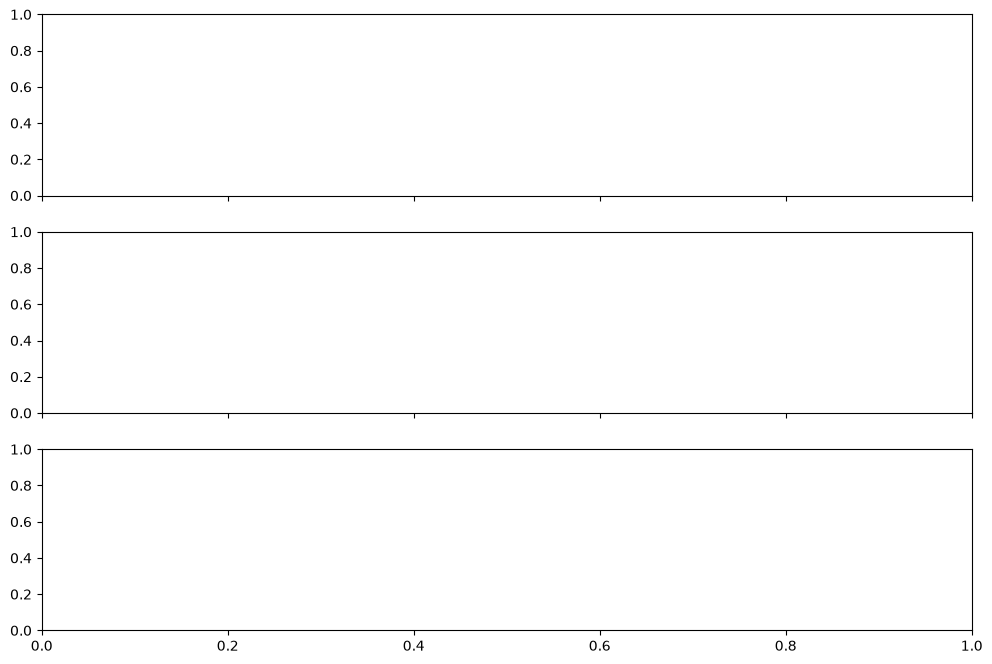

In [9]:
# Find the cell closest to Newark Liberty Airport (EWR)
cell_id = mpasd.latlon2cellid(40.6895, -74.1745)
print(f"Nearest cell ID: {cell_id}")

# Extract time series for this cell from the subset
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

times = nj_sub['time'].values

axes[0].plot(times, nj_sub['t2m'].sel(face=cell_id).values, 'r-')
axes[0].set_ylabel('T\u2082\u2098 (K)')
axes[0].set_title('Newark Airport (EWR) \u2014 Time Series')
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, nj_sub['wind_speed_10m'].sel(face=cell_id).values, 'b-')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(times, nj_sub['rain_rate'].sel(face=cell_id).values, 'g-')
axes[2].set_ylabel('Rain Rate (mm/hr)')
axes[2].set_xlabel('Time')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()